1. Introdução e Contexto

Este notebook tem como objetivo realizar uma Exploratory Data Analysis (EDA), essencial para a compreensão inicial do dataset. O foco principal é um problema de Classificação, onde pretendemos prever a aptidão física de um indivíduo.

- Repositório: https://www.kaggle.com/datasets/kukuroo3/body-performance-data
- Finalidade: Preparar os dados, identificar padrões, avaliar a qualidade das features e entender a distribuição da variável-alvo.


2. Justificação e Estrutura do Dataset

O dataset em questão é uma coleção de medições de aptidão física e características demográficas, com o objetivo de classificar um indivíduo numa das classes de desempenho.

- Variável-Alvo (class): A coluna class (A, B, C, D) é a variável que pretendemos prever.

- Variáveis Preditivas (Features): Incluem características demográficas (age, gender), medidas corporais (height_cm, weight_kg, body fat_%), métricas de saúde (diastolic, systolic) e resultados de testes físicos (gripForce, sit and bend forward_cm, sit-ups counts, broad jump_cm).

- Contexto da Classificação: Para modelos de classificação, o EDA deve concentrar-se em:

  - Distribuição da Classe: O dataset está equilibrado?

  - Diferenças entre Classes: As features numéricas têm distribuições diferentes para cada classe?

  - Relação Feature-Classe: Que features parecem ser as mais discriminatórias?

Objetivos da EDA

- Avaliar a Qualidade e Estrutura dos dados (tipos, valores em falta).

- Analisar o Desequilíbrio da variável-alvo (class).

- Identificar as features mais discriminatórias (que melhor separam as classes).

3. Carregamento, Estrutura e Estatísticas Descritivas


Este capitulo carrega o dataset e realiza a primeira inspeção para verificar dimensões, tipos de dados e a presença de valores em falta.

In [16]:
# Importa as bibliotecas essenciais para manipulação, visualização e cálculo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carrega o dataset
dataset_path = "bodyPerformance.csv" # Define o caminho do ficheiro de dados
df = pd.read_csv(dataset_path) # Carrega o ficheiro CSV para um DataFrame do Pandas, chamado 'df'

print("Dimensões do Dataset:", df.shape) # Imprime as dimensões do DataFrame: (número de linhas, número de colunas)
print("\nTipos de Dados:") 
print(df.dtypes)
print("\nValores em falta:")
print(df.isna().sum())
print("\nEstatísticas Descritivas:")
print(df.describe())

Dimensões do Dataset: (13393, 12)

Tipos de Dados:
age                        float64
gender                      object
height_cm                  float64
weight_kg                  float64
body fat_%                 float64
diastolic                  float64
systolic                   float64
gripForce                  float64
sit and bend forward_cm    float64
sit-ups counts             float64
broad jump_cm              float64
class                       object
dtype: object

Valores em falta:
age                        0
gender                     0
height_cm                  0
weight_kg                  0
body fat_%                 0
diastolic                  0
systolic                   0
gripForce                  0
sit and bend forward_cm    0
sit-ups counts             0
broad jump_cm              0
class                      0
dtype: int64

Estatísticas Descritivas:
                age     height_cm     weight_kg    body fat_%     diastolic  \
count  13393.000000  13393.00

Interpretação dos Resultados (Carregamento)

- Dimensões: O dataset possui 13393 linhas e 12 colunas.

- Qualidade: A contagem de valores em falta (df.isna().sum()) indica que o dataset é limpo, pois não existem missing values em nenhuma das colunas.

- Estatísticas Descritivas: O df.describe() fornece um resumo das features numéricas.

4. Análise da Variável-Alvo (class)

Antes de construir qualquer modelo, é crucial entender a distribuição da variável que se pretende prever.

Contagem de Classes:
class
C    3349
D    3349
A    3348
B    3347
Name: count, dtype: int64


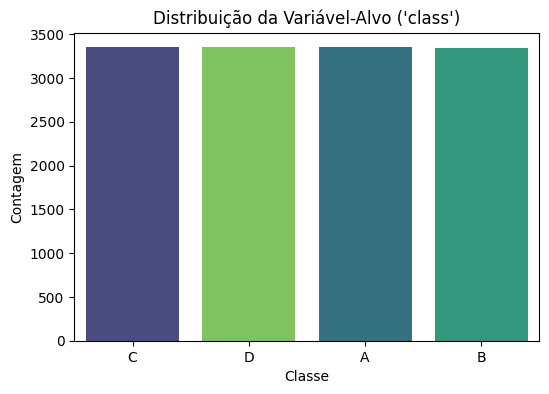

In [17]:
class_counts = df['class'].value_counts() # Conta o número de ocorrências de cada valor único na coluna 'class'

print("Contagem de Classes:")
print(class_counts)

plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=df, order=class_counts.index, hue='class', palette='viridis', legend=False) # Cria um gráfico de barras para a contagem da variável 'class'
plt.title("Distribuição da Variável-Alvo ('class')")
plt.xlabel("Classe")
plt.ylabel("Contagem")
plt.show() 

Interpretação dos Resultados (Distribuição de Classes)

O gráfico de contagem revela o balanço do nosso problema de classificação.

5. Análise Bivariada: Poder Discriminatório das Features

Nesta secção, exploramos como as features numéricas se distribuem em função das classes. Os Boxplots são a ferramenta ideal para avaliar o poder discriminatório de um preditor.

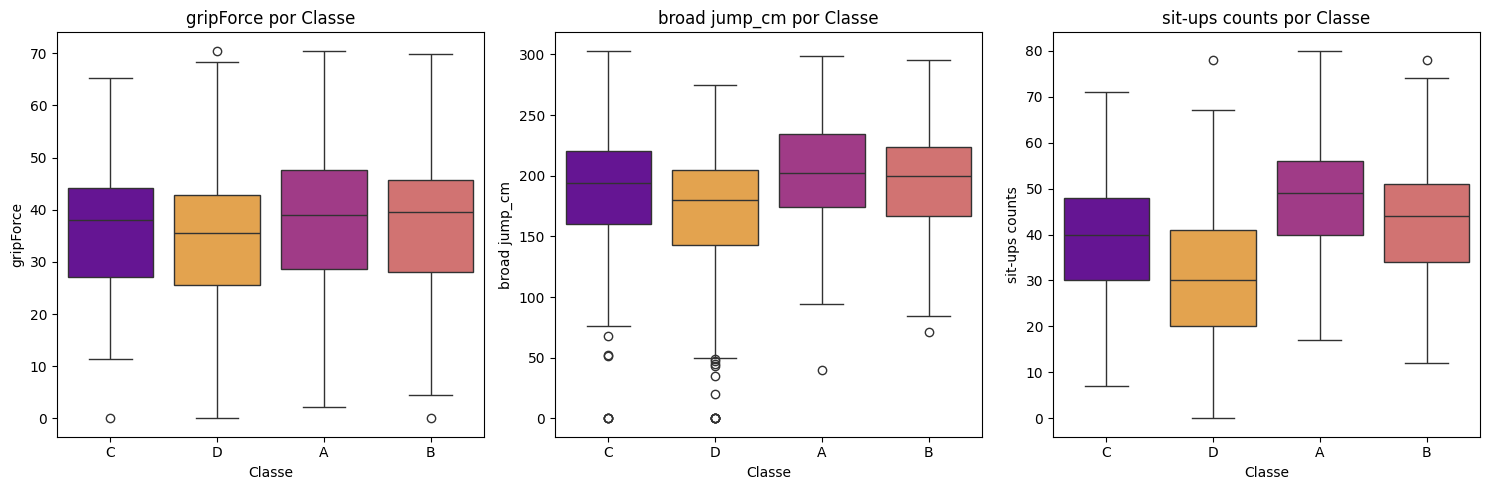

In [18]:
key_features = ['gripForce', 'broad jump_cm', 'sit-ups counts'] # Lista de features de desempenho físico a serem analisadas

plt.figure(figsize=(15, 5))
for i, feature in enumerate(key_features):
    plt.subplot(1, 3, i + 1)

    sns.boxplot(x='class', y=feature, data=df, order=class_counts.index, palette='plasma', hue='class', legend=False)
    plt.title(f'{feature} por Classe')
    plt.xlabel('Classe')
    plt.ylabel(feature)

plt.tight_layout()
plt.show() 

6. Relação da Variável Categórica (gender) com a Classe

Analisamos o impacto da variável gender na distribuição da classe de desempenho.

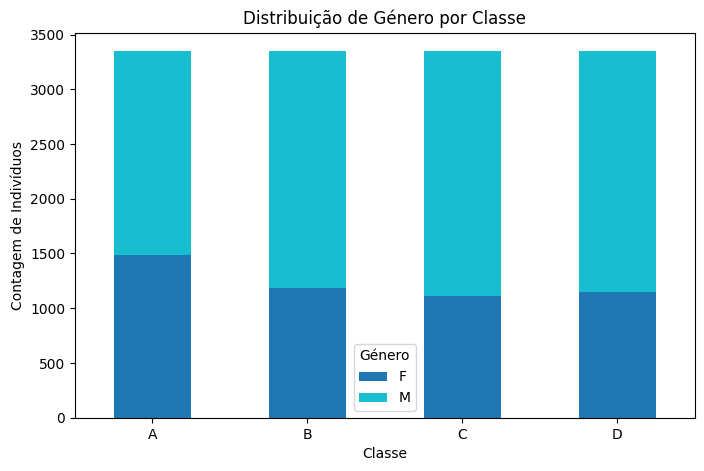

In [19]:
# Cria uma tabela dinâmica (pivot) para contar a ocorrência de cada género em cada classe
gender_class_pivot = df.groupby(['class', 'gender']).size().unstack(fill_value=0)
gender_class_pivot.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='tab10')
plt.title("Distribuição de Género por Classe")
plt.xlabel("Classe")
plt.ylabel("Contagem de Indivíduos")
plt.xticks(rotation=0)
plt.legend(title='Género')
plt.show() 

7. Matriz de Correlação das Variáveis Numéricas

A matriz de correlação mede a relação linear entre todos os pares de features numéricas.

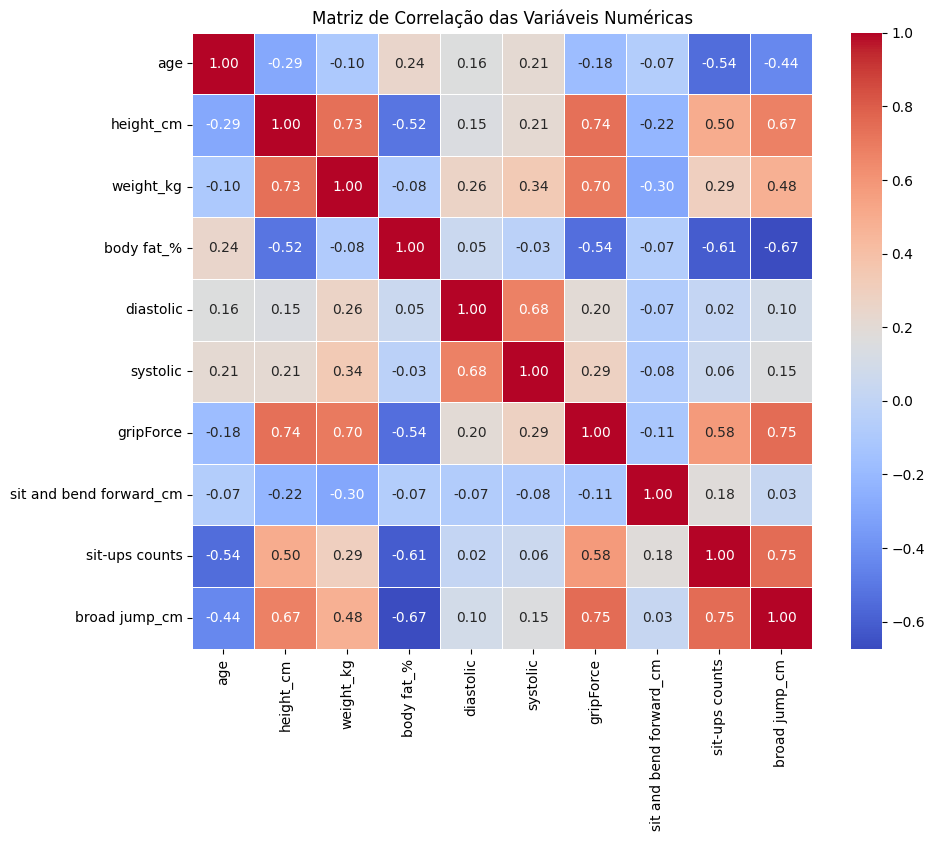

In [20]:
numeric_df = df.drop(columns=['gender', 'class']) # Cria um novo DataFrame apenas com as colunas numéricas (excluindo as categóricas)


corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title("Matriz de Correlação das Variáveis Numéricas")
plt.show() 

8. Preparação Final e Exportação do Dataset

As etapas finais do EDA incluem a codificação da variável categórica (gender) para a tornar utilizável pelos algoritmos e a exportação do ficheiro final.



8.1. Codificação da Variável Categórica

A coluna gender é codificada usando One-Hot Encoding, criando a coluna is_male (1 para Masculino, 0 para Feminino).

In [21]:
# Codificação da variável 'gender'
df_encoded = pd.get_dummies(df, columns=['gender'], drop_first=True) 

X = df_encoded.drop('class', axis=1) 
y = df_encoded['class'] 

print("\nPré-visualização de X (Features):")
print(X.head())


Pré-visualização de X (Features):
    age  height_cm  weight_kg  body fat_%  diastolic  systolic  gripForce  \
0  27.0      172.3      75.24        21.3       80.0     130.0       54.9   
1  25.0      165.0      55.80        15.7       77.0     126.0       36.4   
2  31.0      179.6      78.00        20.1       92.0     152.0       44.8   
3  32.0      174.5      71.10        18.4       76.0     147.0       41.4   
4  28.0      173.8      67.70        17.1       70.0     127.0       43.5   

   sit and bend forward_cm  sit-ups counts  broad jump_cm  gender_M  
0                     18.4            60.0          217.0      True  
1                     16.3            53.0          229.0      True  
2                     12.0            49.0          181.0      True  
3                     15.2            53.0          219.0      True  
4                     27.1            45.0          217.0      True  


8.2. Exportação do Ficheiro Final

Guardamos o DataFrame codificado e completo (df_encoded) para ser carregado diretamente na fase de modelação e teste.

In [22]:
# Renomeação da coluna codificada para clareza
if 'gender_M' in df_encoded.columns:
    df_encoded.rename(columns={'gender_M': 'is_male'}, inplace=True)
elif 'gender_F' in df_encoded.columns:
    df_encoded.rename(columns={'gender_F': 'is_female'}, inplace=True)

# Exportação do DataFrame
output_path = "prepared_classification.csv"

# Exporta o DataFrame final e processado para um ficheiro CSV
df_encoded.to_csv(output_path, index=False)

print("\nFicheiro exportado com sucesso em prepared_classification.csv")
print("\nficheiro exportado:")
print(df_encoded.head())


Ficheiro exportado com sucesso em prepared_classification.csv

ficheiro exportado:
    age  height_cm  weight_kg  body fat_%  diastolic  systolic  gripForce  \
0  27.0      172.3      75.24        21.3       80.0     130.0       54.9   
1  25.0      165.0      55.80        15.7       77.0     126.0       36.4   
2  31.0      179.6      78.00        20.1       92.0     152.0       44.8   
3  32.0      174.5      71.10        18.4       76.0     147.0       41.4   
4  28.0      173.8      67.70        17.1       70.0     127.0       43.5   

   sit and bend forward_cm  sit-ups counts  broad jump_cm class  is_male  
0                     18.4            60.0          217.0     C     True  
1                     16.3            53.0          229.0     A     True  
2                     12.0            49.0          181.0     C     True  
3                     15.2            53.0          219.0     B     True  
4                     27.1            45.0          217.0     B     True  


Interpretação dos Resultados (Exportação)

O dataset prepared_classification.csv está agora guardado. Contém todas as features e a variável-alvo, sendo o ponto de partida ideal para a aplicação de algoritmos de Classificação.
